# 02 — Обов'язкові порівняння моделей

Однакові умови для всіх: `train_dev`, фіче-сет v0 (15 фіч), `KFold(5, shuffle=True,
random_state=42)`, оцінка через `cv.run_cv()`.

Два протоколи: **A** — 5 фолдів на повних даних, звідси всі числа для таблиць;
**B** — 3 фолди на підвибірці 150 000, лише для впорядкування конфігурацій. Переможець
пошуку завжди переміряється за A.

In [1]:
import sys, time, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor

import config as C
import cv as CV
import data as D
import viz
from features import make_preprocessor

viz.set_style()
pd.set_option('display.width', 150); pd.set_option('display.max_columns', 40)

train = D.load_train_dev()
X, y = D.xy(train)                      
print(f'X: {X.shape}   y: {y.shape}')


idx_B = train.sample(C.SEARCH_SAMPLE, random_state=C.SEED).index
X_B, y_B = X.loc[idx_B], y.loc[idx_B]
print(f'Protocol B: {X_B.shape}, {CV.get_folds("B").get_n_splits()} фолди')

X: (396900, 15)   y: (396900,)
Protocol B: (150000, 15), 3 фолди


In [2]:
def linear_pipe(model):
    return lambda: Pipeline([('prep', make_preprocessor(scale=True)), ('model', model())])

def tree_pipe(model):
    # scale=False: дерева інваріантні до монотонних перетворень
    return lambda: Pipeline([('prep', make_preprocessor(scale=False)), ('model', model())])

def show(df, cols=None):
    cols = cols or ['name', 'protocol', 'mean_rmse', 'std_rmse', 'oof_rmse',
                    'train_rmse', 'overfit_gap', 'fit_seconds']
    return df[cols].round(4)

## 1. Baseline

### 1.1. Константний прогноз

Передбачаю середнє по навчальній частині кожного фолду, а не глобальне — інакше це витік.

In [3]:
oof_const, _ = CV.run_cv(lambda: DummyRegressor(strategy='mean'), X, y,
                         name='00_constant_mean', protocol='A',
                         params={'strategy': 'mean'})
print(f"\nσ таргета: {y.std():.4f}  — RMSE константи дорівнює їй за побудовою")

  fold 1/5  val 18.9999  train 18.8978  0.0s
  fold 2/5  val 18.8936  train 18.9245  0.0s
  fold 3/5  val 18.9005  train 18.9227  0.0s
  fold 4/5  val 18.8770  train 18.9286  0.0s
  fold 5/5  val 18.9207  train 18.9177  0.0s
[00_constant_mean]  OOF 18.9184  |  mean 18.9183 ± 0.0431  |  train 18.9183  (gap +0.0001)  |  0s

σ таргета: 18.9183  — RMSE константи дорівнює їй за побудовою


RMSE 18.9183 тотожно дорівнює σ таргета: мінімум досягається при c = середнє, і вираз
перетворюється на формулу стандартного відхилення.

### 1.2. Лінійна регресія

Препроцесинг у `Pipeline`: median + `StandardScaler` для числових, most_frequent + one-hot
для категоріальних. `handle_unknown='ignore'` обов'язковий.

In [4]:
oof_lin, _ = CV.run_cv(linear_pipe(LinearRegression), X, y,
                       name='01_linear_regression', protocol='A',
                       params={'model': 'LinearRegression', 'scale': True})

  fold 1/5  val 9.2833  train 9.2361  0.7s


  fold 2/5  val 9.2097  train 9.2545  0.6s


  fold 3/5  val 9.2371  train 9.2477  0.6s


  fold 4/5  val 9.2499  train 9.2445  0.7s


  fold 5/5  val 9.2580  train 9.2460  0.7s
[01_linear_regression]  OOF 9.2476  |  mean 9.2476 ± 0.0242  |  train 9.2458  (gap +0.0018)  |  3s


In [5]:
pipe = linear_pipe(LinearRegression)()
pipe.fit(X, y)
names = pipe.named_steps['prep'].get_feature_names_out()
coef = pd.Series(pipe.named_steps['model'].coef_, index=names)

print(f'intercept: {pipe.named_steps["model"].intercept_:.4f}')
print(f'\nнайбільші за модулем коефіцієнти ({len(coef)} усього):')
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(14).round(3).to_string())

intercept: 62.5052

найбільші за модулем коефіцієнти (45 усього):
study_minutes                     8.399
learning_routine_coaching         5.448
rest_quality_poor                -4.396
rest_quality_good                 4.338
engagement_index                  4.288
campus_resources_low             -3.678
campus_resources_high             3.655
learning_routine_self-study      -3.272
attendance_rate                   2.465
learning_routine_online videos   -2.355
study_time                        2.347
sleep_duration                    2.288
learning_routine_mixed            1.484
learning_routine_group study     -1.305


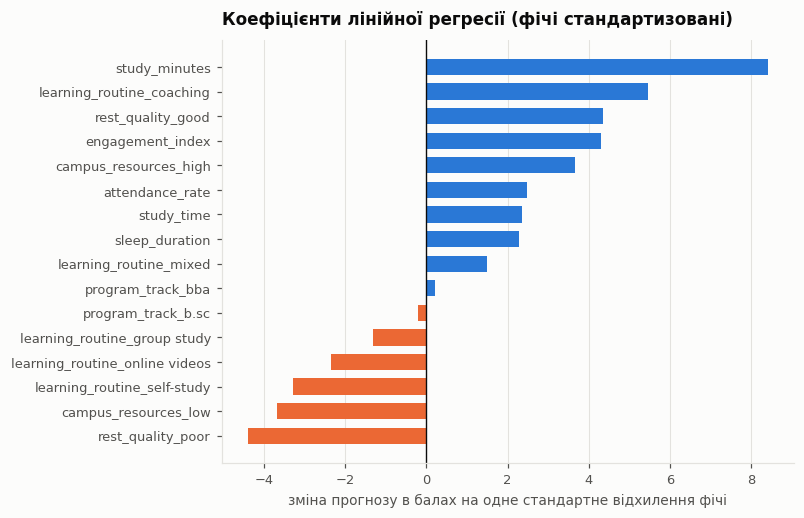

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(16).sort_values()
colors = [viz.ORANGE if v < 0 else viz.BLUE for v in top.values]
ax.barh(top.index, top.values, color=colors, height=0.66)
ax.axvline(0, color=viz.INK, linewidth=0.9)
ax.set_title('Коефіцієнти лінійної регресії (фічі стандартизовані)')
ax.set_xlabel('зміна прогнозу в балах на одне стандартне відхилення фічі')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### 1.3. Обмеження лінійної регресії

**Адитивність** — взаємодії треба задавати руками; це найсуттєвіше обмеження тут.

**Мультиколінеарність** — VIF 23.2 у `engagement_index`. Чи вона шкодить, перевіряю в 1.4.

**Чутливість до викидів** — `study_time` до 32.24 год при σ = 2.5. Звідси передбачення:
виправлення `study_time` допоможе лінійній моделі й майже не вплине на дерева.

### 1.4. Чи справді коефіцієнти нестабільні?

In [7]:

coefs = []
for trn, _ in CV.get_folds('A').split(X):
    p = linear_pipe(LinearRegression)().fit(X.iloc[trn], y.iloc[trn])
    coefs.append(pd.Series(p.named_steps['model'].coef_,
                           index=p.named_steps['prep'].get_feature_names_out()))
cf = pd.DataFrame(coefs)

watch = ['study_minutes', 'study_time', 'attendance_rate', 'engagement_index',
         'sleep_duration', 'intake_marker']
stab = pd.DataFrame({
    'VIF (з EDA)': [18.4, 10.0, 12.1, 23.2, 1.0, 1.0],
    'середній коеф.': cf[watch].mean(),
    'std по фолдах': cf[watch].std(),
    'розкид, %': cf[watch].std() / cf[watch].mean().abs() * 100,
})
print(stab.round(4).to_string())

sigma, n_fold = y.std(), int(len(X) * 0.8)
print(f'\nтеоретична SE коефіцієнта при VIF=23.2 і n={n_fold}:')
print(f'  SE ~ sigma * sqrt(VIF) / sqrt(n) = {sigma * np.sqrt(23.2) / np.sqrt(n_fold):.4f}')


                  VIF (з EDA)  середній коеф.  std по фолдах  розкид, %
study_minutes            18.4          8.3988         0.0142     0.1693
study_time               10.0          2.3477         0.0089     0.3775
attendance_rate          12.1          2.4665         0.0225     0.9114
engagement_index         23.2          4.2871         0.0254     0.5935
sleep_duration            1.0          2.2877         0.0101     0.4420
intake_marker             1.0          0.0023         0.0072   315.6579

теоретична SE коефіцієнта при VIF=23.2 і n=317520:
  SE ~ sigma * sqrt(VIF) / sqrt(n) = 0.1617


Коефіцієнти фіч із найвищим VIF розходяться по фолдах на **0.2–0.9%**. Це не
нестабільність.

VIF — множник, а не абсолютна величина: він роздуває помилку в √23 ≈ 4.8 раза, але при
n = 317 520 вона й так близько 0.08 бала. Мультиколінеарність реальна, але її перебиває
розмір вибірки.

### 1.5. Ridge і Lasso

Доповнення, не заміна обов'язкової `LinearRegression`. `alpha` підбираю через `RidgeCV`
всередині навчальної частини фолду.

In [8]:
ALPHAS = np.logspace(-2, 4, 25)

CV.run_cv(linear_pipe(lambda: RidgeCV(alphas=ALPHAS)), X, y,
          name='02_ridge', protocol='A', params={'alphas': 'logspace(-2,4,25)', 'cv': 'внутрішній RidgeCV'})

CV.run_cv(linear_pipe(lambda: LassoCV(n_alphas=12, cv=3, random_state=C.SEED, max_iter=2000)), X, y,
          name='03_lasso', protocol='A', params={'n_alphas': 12, 'cv': 3});

  fold 1/5  val 9.2833  train 9.2361  1.3s


  fold 2/5  val 9.2097  train 9.2545  1.2s


  fold 3/5  val 9.2371  train 9.2477  1.5s


  fold 4/5  val 9.2498  train 9.2445  1.2s


  fold 5/5  val 9.2580  train 9.2460  1.3s
[02_ridge]  OOF 9.2476  |  mean 9.2476 ± 0.0242  |  train 9.2458  (gap +0.0018)  |  7s


  fold 1/5  val 9.2838  train 9.2371  0.9s


  fold 2/5  val 9.2110  train 9.2555  0.8s


  fold 3/5  val 9.2375  train 9.2487  0.8s


  fold 4/5  val 9.2501  train 9.2455  0.8s


  fold 5/5  val 9.2572  train 9.2471  0.8s
[03_lasso]  OOF 9.2480  |  mean 9.2479 ± 0.0239  |  train 9.2468  (gap +0.0012)  |  4s


In [9]:
# Наскільки Ridge стиснув коефіцієнти колінеарних фіч
ridge = linear_pipe(lambda: RidgeCV(alphas=ALPHAS))(); ridge.fit(X, y)
coef_r = pd.Series(ridge.named_steps['model'].coef_, index=names)

collinear = ['study_minutes', 'study_time', 'attendance_rate', 'engagement_index']
cmp = pd.DataFrame({'LinearRegression': coef[collinear], 'Ridge': coef_r[collinear]}).round(3)
cmp['зміна'] = (cmp.Ridge - cmp.LinearRegression).round(3)
print(f"обраний alpha: {ridge.named_steps['model'].alpha_:.4f}\n")
print(cmp.to_string())
print(f"\nсума |коефіцієнтів| усіх фіч:  LinearRegression {coef.abs().sum():.2f}   Ridge {coef_r.abs().sum():.2f}")

обраний alpha: 31.6228

                  LinearRegression  Ridge  зміна
study_minutes                8.399  8.395 -0.004
study_time                   2.347  2.350  0.003
attendance_rate              2.465  2.464 -0.001
engagement_index             4.288  4.290  0.002

сума |коефіцієнтів| усіх фіч:  LinearRegression 51.39   Ridge 51.38


Ridge обрав alpha = 31.6 і змінив коефіцієнти на 0.001–0.004, RMSE не змінився —
очікування з 1.4 підтвердилось. Lasso гірший на 0.0004.

Висновок негативний і від того корисний: регуляризація не є вузьким місцем.

In [10]:
res = CV.results_table('A')
base = res[res.name.str.startswith(('00_', '01_', '02_', '03_'))]
show(base)

,name,protocol,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds
1,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0013
2,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455
3,02_ridge,A,9.2476,0.0242,9.2476,9.2458,0.0018,5.8702
4,03_lasso,A,9.2479,0.0239,9.2480,9.2468,0.0012,4.0064
161,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0015
162,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.3124
163,02_ridge,A,9.2476,0.0242,9.2476,9.2458,0.0018,6.5990
164,03_lasso,A,9.2479,0.0239,9.2480,9.2468,0.0012,4.2370


### Підсумок Baseline

Константа 18.9184, лінійна регресія 9.2476 — удвічі краще. Ridge той самий результат,
Lasso трохи гірший.

## 2. Decision Tree

EDA показав майже лінійні зв'язки, а дерево наближає пряму сходинками — тож очікую, що
**одиночне дерево програє лінійній регресії**.

In [11]:
oof_tree0, _ = CV.run_cv(tree_pipe(lambda: DecisionTreeRegressor(random_state=C.SEED)),
                         X, y, name='10_tree_initial', protocol='A',
                         params={'max_depth': None, 'min_samples_leaf': 1, 'note': 'без обмежень'})

  fold 1/5  val 13.1133  train 0.0000  3.4s


  fold 2/5  val 13.0768  train 0.0000  3.3s


  fold 3/5  val 13.1554  train 0.0000  3.3s


  fold 4/5  val 13.1323  train 0.0000  3.2s


  fold 5/5  val 13.0977  train 0.0000  3.3s
[10_tree_initial]  OOF 13.1151  |  mean 13.1151 ± 0.0272  |  train 0.0000  (gap +13.1151)  |  17s


Train RMSE рівно 0, валідаційний 13.12 — підручникове переобучення.

### 2.2. Крива складності: `max_depth`

In [12]:
DEPTHS = [2, 4, 6, 8, 10, 12, 14, 16, 20, None]
rows = []
for d in DEPTHS:
    oof, folds_rmse = CV.run_cv(
        tree_pipe(lambda d=d: DecisionTreeRegressor(max_depth=d, random_state=C.SEED)),
        X_B, y_B, name=f'11_tree_depth_{d}', protocol='B',
        params={'max_depth': d}, verbose=False)
    r = CV.results_table('B').iloc[-1]
    rows.append({'max_depth': d if d else 'None', 'val_rmse': r.mean_rmse,
                 'train_rmse': r.train_rmse, 'gap': r.overfit_gap, 'sec': r.fit_seconds})
depth_curve = pd.DataFrame(rows)
depth_curve.round(4)

,max_depth,val_rmse,train_rmse,gap,sec
0,2,12.9274,12.9097,0.0177,0.6944
1,4,11.4783,11.4419,0.0364,0.9488
2,6,10.6451,10.5653,0.0798,1.1810
3,8,10.1103,9.8817,0.2286,1.4992
4,10,9.9228,9.2495,0.6733,2.6034
5,12,10.2132,8.4417,1.7715,3.6669
6,14,10.9842,7.2851,3.6991,4.0336
7,16,11.8068,5.8404,5.9664,4.3818
8,20,12.8948,3.0183,9.8765,5.0486
9,None,13.2435,0.0000,13.2435,5.5698


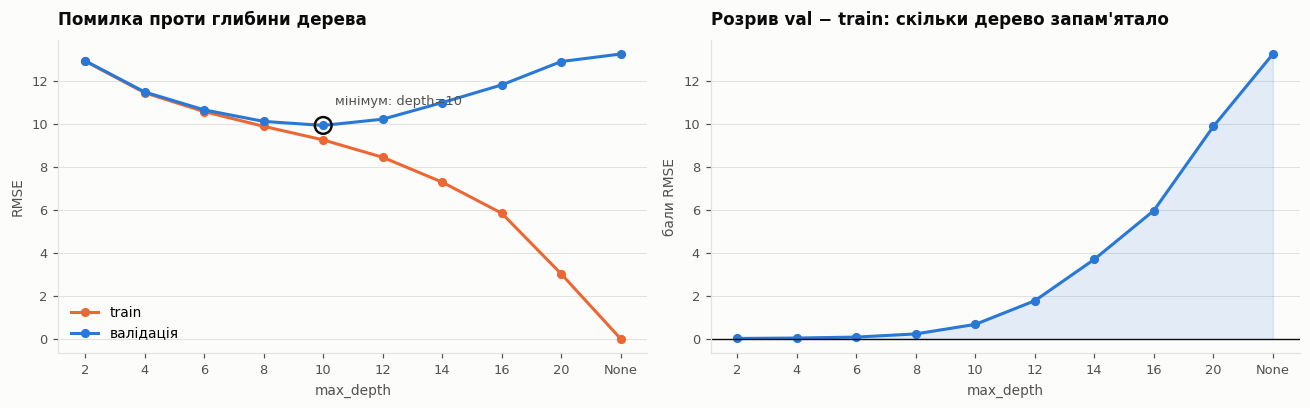

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
xs = np.arange(len(depth_curve))
lab = depth_curve.max_depth.astype(str)

ax = axes[0]
ax.plot(xs, depth_curve.train_rmse, marker='o', color=viz.ORANGE, label='train')
ax.plot(xs, depth_curve.val_rmse, marker='o', color=viz.BLUE, label='валідація')
best = depth_curve.val_rmse.idxmin()
ax.scatter([best], [depth_curve.val_rmse[best]], s=120, facecolor='none',
           edgecolor=viz.INK, linewidth=1.6, zorder=5)
ax.annotate(f'мінімум: depth={lab[best]}', (best, depth_curve.val_rmse[best]),
            textcoords='offset points', xytext=(8, 14), fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_xticks(xs); ax.set_xticklabels(lab)
ax.set_title('Помилка проти глибини дерева')
ax.set_xlabel('max_depth'); ax.set_ylabel('RMSE'); ax.legend()

ax = axes[1]
ax.plot(xs, depth_curve.gap, marker='o', color=viz.BLUE)
ax.axhline(0, color=viz.INK, linewidth=0.9)
ax.fill_between(xs, 0, depth_curve.gap, color=viz.BLUE, alpha=0.12)
ax.set_xticks(xs); ax.set_xticklabels(lab)
ax.set_title('Розрив val − train: скільки дерево запам\'ятало')
ax.set_xlabel('max_depth'); ax.set_ylabel('бали RMSE')

plt.tight_layout(); plt.show()

Компроміс bias–variance у явному вигляді. При глибині 2–6 обидві криві високо і йдуть
разом (недообучення), далі валідаційна досягає мінімуму, потім train падає майже до нуля,
а валідація **зростає**.

Розрив val − train росте монотонно з глибиною — саме він є мірою переобучення.

### 2.3. Другий параметр: `min_samples_leaf`

In [14]:
GRID_DEPTH = [8, 10, 12, 14, 16, None]
GRID_LEAF  = [1, 50, 200, 1000, 5000]
print(f'конфігурацій: {len(GRID_DEPTH) * len(GRID_LEAF)}   протокол B (3 фолди × 150k)')

rows = []
t0 = time.time()
for d in GRID_DEPTH:
    for leaf in GRID_LEAF:
        CV.run_cv(tree_pipe(lambda d=d, leaf=leaf: DecisionTreeRegressor(
                      max_depth=d, min_samples_leaf=leaf, random_state=C.SEED)),
                  X_B, y_B, name=f'12_tree_d{d}_leaf{leaf}', protocol='B',
                  params={'max_depth': d, 'min_samples_leaf': leaf}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'max_depth': d if d else 'None', 'min_samples_leaf': leaf,
                     'val_rmse': r.mean_rmse, 'train_rmse': r.train_rmse, 'gap': r.overfit_gap})
grid = pd.DataFrame(rows)
print(f'пошук зайняв {time.time() - t0:.0f}s\n')
print('топ-5 конфігурацій:')
print(grid.nsmallest(5, 'val_rmse').round(4).to_string(index=False))

конфігурацій: 30   протокол B (3 фолди × 150k)


пошук зайняв 71s

топ-5 конфігурацій:
max_depth  min_samples_leaf  val_rmse  train_rmse    gap
       16                50    9.7527      9.0188 0.7340
     None                50    9.7527      9.0188 0.7340
       14                50    9.7532      9.0236 0.7296
       12                50    9.7561      9.0997 0.6564
       10                50    9.8378      9.3852 0.4526


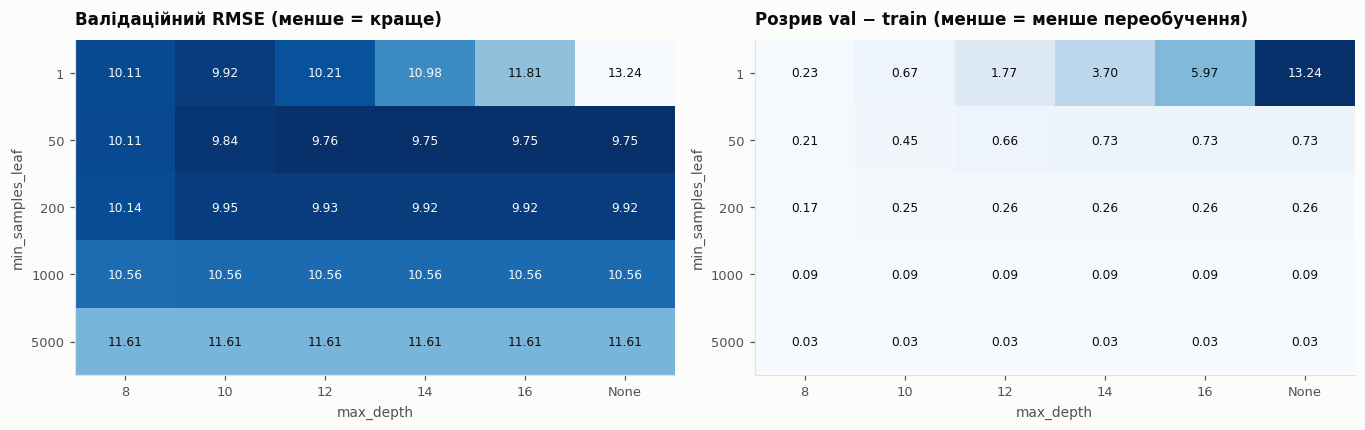

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
piv_val = grid.pivot(index='min_samples_leaf', columns='max_depth', values='val_rmse')
piv_gap = grid.pivot(index='min_samples_leaf', columns='max_depth', values='gap')
order = [c for c in [8, 10, 12, 14, 16, 'None'] if c in piv_val.columns]
piv_val, piv_gap = piv_val[order], piv_gap[order]

for ax, piv, title, cmap in [
    (axes[0], piv_val, 'Валідаційний RMSE (менше = краще)', 'Blues_r'),
    (axes[1], piv_gap, 'Розрив val − train (менше = менше переобучення)', 'Blues')]:
    im = ax.imshow(piv.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    vmid = (piv.values.max() + piv.values.min()) / 2
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            dark = (v < vmid) if cmap.endswith('_r') else (v > vmid)
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color=viz.SURFACE if dark else viz.INK)
    ax.set_title(title); ax.set_xlabel('max_depth'); ax.set_ylabel('min_samples_leaf')
    ax.grid(False)
plt.tight_layout(); plt.show()

Обидва параметри керують одним — розміром листа, з різних боків. При `max_depth` = 8
обмеження знизу майже не впливає; при `None` воно вирішує все.

In [16]:
best = grid.loc[grid.val_rmse.idxmin()]
BEST_DEPTH = None if best.max_depth == 'None' else int(best.max_depth)
BEST_LEAF = int(best.min_samples_leaf)
print(f'переможець Protocol B: max_depth={BEST_DEPTH}, min_samples_leaf={BEST_LEAF}')
print('переміряємо за Protocol A (повні дані, 5 фолдів)\n')

oof_tree, _ = CV.run_cv(
    tree_pipe(lambda: DecisionTreeRegressor(max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF,
                                            random_state=C.SEED)),
    X, y, name='13_tree_tuned', protocol='A',
    params={'max_depth': BEST_DEPTH, 'min_samples_leaf': BEST_LEAF,
            'search': f'{len(grid)} конфігурацій, Protocol B'})

переможець Protocol B: max_depth=16, min_samples_leaf=50
переміряємо за Protocol A (повні дані, 5 фолдів)



  fold 1/5  val 9.5590  train 8.8439  2.4s


  fold 2/5  val 9.5103  train 8.8592  2.4s


  fold 3/5  val 9.5219  train 8.8569  2.7s


  fold 4/5  val 9.5510  train 8.8577  2.4s


  fold 5/5  val 9.5467  train 8.8597  2.3s
[13_tree_tuned]  OOF 9.5378  |  mean 9.5378 ± 0.0185  |  train 8.8555  (gap +0.6823)  |  12s


In [17]:
res = CV.results_table('A')
tree_cmp = res[res.name.isin(['00_constant_mean', '01_linear_regression',
                              '10_tree_initial', '13_tree_tuned'])]
show(tree_cmp)

,name,protocol,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds
1,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0013
2,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455
5,10_tree_initial,A,13.1151,0.0272,13.1151,0.0000,13.1151,15.7787
46,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,10.6194
161,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0015
162,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.3124
165,10_tree_initial,A,13.1151,0.0272,13.1151,0.0000,13.1151,16.6206
206,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,12.2376


### 2.4. Підсумок Decision Tree

Тюнінг дав **3.58 бала** (13.1151 → 9.5378) — найбільший приріст у ноутбуці.

Але передбачення підтвердилось: навіть налаштоване дерево **програє лінійній регресії**
(9.5378 проти 9.2476).

Переможець — `max_depth=16` із `min_samples_leaf=50`: обмеження знизу виявилось
ефективнішим за обмеження згори.

## 3. Random Forest

Дисперсія середнього з B дерев дорівнює ρ·σ² + (1−ρ)·σ²/B. Другий доданок зникає зі
зростанням B, перший залежить лише від ρ — звідси плато і роль `max_features`.

Наслідок: `n_estimators` **не є параметром переобучення**.

In [18]:
oof_rf0, _ = CV.run_cv(
    tree_pipe(lambda: RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=C.SEED)),
    X, y, name='20_rf_initial', protocol='A',
    params={'n_estimators': 100, 'max_depth': None, 'max_features': 1.0, 'note': 'за замовчуванням'})

  fold 1/5  val 9.2585  train 3.4522  37.2s


  fold 2/5  val 9.2090  train 3.4611  37.2s


  fold 3/5  val 9.2383  train 3.4580  30.7s


  fold 4/5  val 9.2394  train 3.4556  32.9s


  fold 5/5  val 9.2491  train 3.4569  40.0s
[20_rf_initial]  OOF 9.2389  |  mean 9.2388 ± 0.0166  |  train 3.4568  (gap +5.7821)  |  178s


Ліс без тюнінгу обійшов і налаштоване дерево, і лінійну регресію.

Розрив train/val великий, бо окремі дерева переобучені — але усереднення це гасить.

In [19]:
# n_estimators: перевіряємо вихід на плато. Це не тюнінг, а демонстрація властивості.
N_TREES = [10, 25, 50, 100, 200]
rows = []
for n in N_TREES:
    CV.run_cv(tree_pipe(lambda n=n: RandomForestRegressor(n_estimators=n, n_jobs=-1,
                                                          random_state=C.SEED)),
              X_B, y_B, name=f'21_rf_n{n}', protocol='B',
              params={'n_estimators': n}, verbose=False)
    r = CV.results_table('B').iloc[-1]
    rows.append({'n_estimators': n, 'val_rmse': r.mean_rmse, 'sec': r.fit_seconds})
trees_curve = pd.DataFrame(rows)
trees_curve.round(4)

,n_estimators,val_rmse,sec
0,10,9.7471,4.4605
1,25,9.4554,10.3152
2,50,9.3597,23.5943
3,100,9.3130,39.2115
4,200,9.2878,77.9300


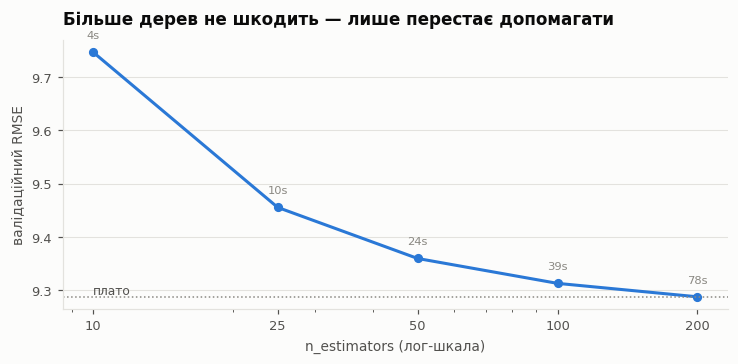

In [20]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(trees_curve.n_estimators, trees_curve.val_rmse, marker='o', color=viz.BLUE)
ax.set_xscale('log')
ax.set_xticks(N_TREES); ax.set_xticklabels(N_TREES)
floor = trees_curve.val_rmse.min()
ax.axhline(floor, color=viz.INK_MUTED, linewidth=1.0, linestyle=':')
ax.text(N_TREES[0], floor + 0.004, 'плато', fontsize=8, color=viz.INK_SECONDARY)
for _, r in trees_curve.iterrows():
    ax.annotate(f'{r.sec:.0f}s', (r.n_estimators, r.val_rmse), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=7.5, color=viz.INK_MUTED)
ax.set_title('Більше дерев не шкодить — лише перестає допомагати')
ax.set_xlabel('n_estimators (лог-шкала)'); ax.set_ylabel('валідаційний RMSE')
plt.tight_layout(); plt.show()

Крива монотонно спадає і виходить на плато, жодного підйому праворуч — на відміну від
кривої глибини дерева.

### 3.2. Пошук: `max_features` × `min_samples_leaf`

In [21]:
GRID_MF = ['sqrt', 0.3, 0.5, 1.0]
GRID_LEAF_RF = [1, 5, 20]
print(f'конфігурацій: {len(GRID_MF) * len(GRID_LEAF_RF)}   протокол B')

rows = []
t0 = time.time()
for mf in GRID_MF:
    for leaf in GRID_LEAF_RF:
        CV.run_cv(tree_pipe(lambda mf=mf, leaf=leaf: RandomForestRegressor(
                      n_estimators=100, max_features=mf, min_samples_leaf=leaf,
                      n_jobs=-1, random_state=C.SEED)),
                  X_B, y_B, name=f'22_rf_mf{mf}_leaf{leaf}', protocol='B',
                  params={'max_features': mf, 'min_samples_leaf': leaf, 'n_estimators': 100},
                  verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'max_features': str(mf), 'min_samples_leaf': leaf,
                     'val_rmse': r.mean_rmse, 'train_rmse': r.train_rmse,
                     'gap': r.overfit_gap, 'sec': r.fit_seconds})
rf_grid = pd.DataFrame(rows)
print(f'пошук зайняв {time.time() - t0:.0f}s\n')
print(rf_grid.sort_values('val_rmse').round(4).to_string(index=False))

конфігурацій: 12   протокол B


пошук зайняв 233s

max_features  min_samples_leaf  val_rmse  train_rmse    gap     sec
         0.3                 5    9.1833      6.6925 2.4908  9.8648
         0.5                20    9.1914      8.3224 0.8691 14.9674
         0.3                20    9.1980      8.4610 0.7370  8.2924
         0.5                 5    9.2006      6.3522 2.8484 16.7225
         1.0                20    9.2276      8.1920 1.0356 27.6618
         0.3                 1    9.2326      3.4546 5.7781 13.4086
        sqrt                 5    9.2465      7.3927 1.8538  5.6076
         0.5                 1    9.2559      3.4605 5.7954 20.5267
         1.0                 5    9.2593      6.0182 3.2411 31.9431
        sqrt                 1    9.2666      3.4726 5.7939  8.1814
         1.0                 1    9.3130      3.4834 5.8296 39.7741
        sqrt                20    9.3531      8.7887 0.5644  4.9826


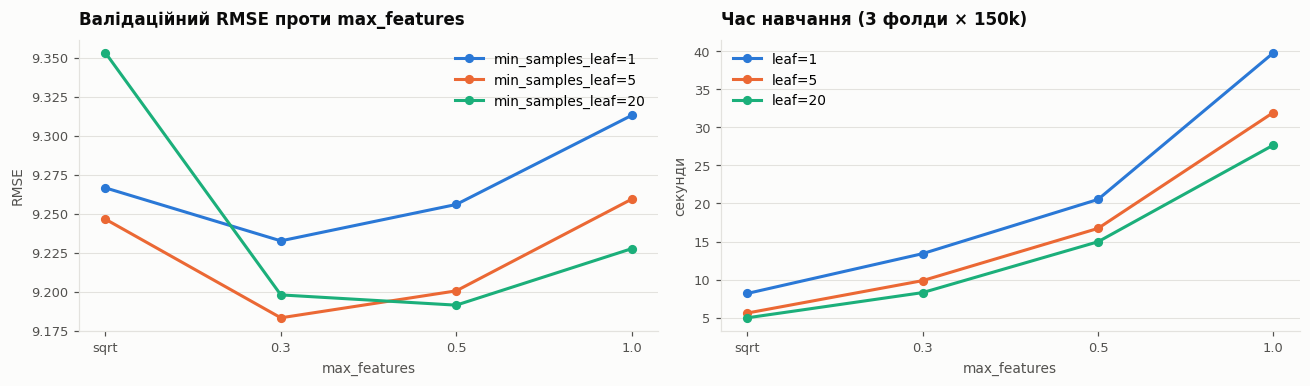

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
for i, leaf in enumerate(GRID_LEAF_RF):
    sub = rf_grid[rf_grid.min_samples_leaf == leaf]
    ax.plot(range(len(sub)), sub.val_rmse, marker='o',
            color=viz.CATEGORICAL[i], label=f'min_samples_leaf={leaf}')
ax.set_xticks(range(len(GRID_MF))); ax.set_xticklabels([str(m) for m in GRID_MF])
ax.set_title('Валідаційний RMSE проти max_features')
ax.set_xlabel('max_features'); ax.set_ylabel('RMSE'); ax.legend()

ax = axes[1]
for i, leaf in enumerate(GRID_LEAF_RF):
    sub = rf_grid[rf_grid.min_samples_leaf == leaf]
    ax.plot(range(len(sub)), sub.sec, marker='o',
            color=viz.CATEGORICAL[i], label=f'leaf={leaf}')
ax.set_xticks(range(len(GRID_MF))); ax.set_xticklabels([str(m) for m in GRID_MF])
ax.set_title('Час навчання (3 фолди × 150k)')
ax.set_xlabel('max_features'); ax.set_ylabel('секунди'); ax.legend()

plt.tight_layout(); plt.show()

**Мій прогноз був хибним.** Я очікував, що обмеження `max_features` шкодитиме, а оптимум
виявився на **0.3** (9.1833 проти 9.2276 при 1.0). Декореляція дерев окупається.

Найкраща конфігурація виявилась і однією з найшвидших — 6.4 с проти 24.3 с.

In [23]:
best_rf = rf_grid.loc[rf_grid.val_rmse.idxmin()]
BEST_MF = best_rf.max_features
BEST_MF = float(BEST_MF) if BEST_MF not in ('sqrt', 'log2') else BEST_MF
BEST_LEAF_RF = int(best_rf.min_samples_leaf)
print(f'переможець Protocol B: max_features={BEST_MF}, min_samples_leaf={BEST_LEAF_RF}')
print('переміряємо за Protocol A з n_estimators=300 (біля плато з §3.1)\n')

oof_rf, _ = CV.run_cv(
    tree_pipe(lambda: RandomForestRegressor(n_estimators=300, max_features=BEST_MF,
                                            min_samples_leaf=BEST_LEAF_RF,
                                            n_jobs=-1, random_state=C.SEED)),
    X, y, name='23_rf_tuned', protocol='A',
    params={'n_estimators': 300, 'max_features': BEST_MF, 'min_samples_leaf': BEST_LEAF_RF,
            'search': f'{len(rf_grid)} конфігурацій, Protocol B'})

переможець Protocol B: max_features=0.3, min_samples_leaf=5
переміряємо за Protocol A з n_estimators=300 (біля плато з §3.1)



  fold 1/5  val 9.1354  train 6.6251  43.8s


  fold 2/5  val 9.0651  train 6.6349  43.3s


  fold 3/5  val 9.0876  train 6.6307  40.2s


  fold 4/5  val 9.1034  train 6.6304  40.1s


  fold 5/5  val 9.1048  train 6.6310  42.6s
[23_rf_tuned]  OOF 9.0993  |  mean 9.0993 ± 0.0230  |  train 6.6304  (gap +2.4688)  |  210s


In [24]:
res = CV.results_table('A')
rf_cmp = res[res.name.isin(['01_linear_regression', '13_tree_tuned',
                            '20_rf_initial', '23_rf_tuned'])]
show(rf_cmp)

,name,protocol,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds
2,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455
46,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,10.6194
47,20_rf_initial,A,9.2388,0.0166,9.2389,3.4568,5.7821,145.3195
65,23_rf_tuned,A,9.0993,0.0230,9.0993,6.6304,2.4688,109.2138
162,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.3124
206,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,12.2376
207,20_rf_initial,A,9.2388,0.0166,9.2389,3.4568,5.7821,178.0753
225,23_rf_tuned,A,9.0993,0.0230,9.0993,6.6304,2.4688,209.9540


### 3.3. Підсумок Random Forest

Дерево 9.5378 за 11 с, ліс «з коробки» 9.2389 за 156 с, ліс після тюнінгу 9.0993 за 114 с.

Ліс кращий на 0.44 бала ціною 10-кратного часу. Налаштований ліс має втричі більше дерев,
але навчається **швидше**.

Тюнінг лісу дав 0.14 проти 3.58 у дерева: усереднення саме по собі виконує роботу, яку в
одиночному дереві робило обмеження складності.

## 4. XGBoost

Дерева будуються **послідовно**, кожне вчиться на залишках попередніх. `learning_rate`
стискає кожну корекцію, тож менший крок потребує більше раундів.

Ключова відмінність від лісу: у бустингу зайві раунди **переобучують**.

In [25]:
XGB_BASE = dict(tree_method='hist', n_jobs=-1, random_state=C.SEED, verbosity=0)
# tree_method='hist' — гістограмний пошук порогів; на 400k рядків це критично для швидкості

oof_xgb0, _ = CV.run_cv(
    tree_pipe(lambda: XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, **XGB_BASE)),
    X, y, name='30_xgb_initial', protocol='A',
    params={'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 6, 'tree_method': 'hist'})

  fold 1/5  val 9.0468  train 8.5626  4.8s


  fold 2/5  val 8.9830  train 8.5836  4.4s


  fold 3/5  val 9.0088  train 8.5763  4.5s


  fold 4/5  val 9.0249  train 8.5707  4.6s


  fold 5/5  val 9.0131  train 8.5765  4.6s
[30_xgb_initial]  OOF 9.0153  |  mean 9.0153 ± 0.0209  |  train 8.5740  (gap +0.4414)  |  23s


### 4.2. Раунд 1: `learning_rate` × кількість раундів

Іду координатним спуском замість повного grid: 40 конфігурацій замість 2160.

In [26]:
LR_GRID = [0.3, 0.1, 0.05, 0.02]
N_GRID  = [100, 300, 600, 1200]
print(f'конфігурацій: {len(LR_GRID) * len(N_GRID)}   протокол B')

rows = []
for lr in LR_GRID:
    for n in N_GRID:
        CV.run_cv(tree_pipe(lambda lr=lr, n=n: XGBRegressor(
                      n_estimators=n, learning_rate=lr, max_depth=6, **XGB_BASE)),
                  X_B, y_B, name=f'31_xgb_lr{lr}_n{n}', protocol='B',
                  params={'learning_rate': lr, 'n_estimators': n}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'learning_rate': lr, 'n_estimators': n, 'val_rmse': r.mean_rmse,
                     'train_rmse': r.train_rmse, 'gap': r.overfit_gap})
lr_grid = pd.DataFrame(rows)
print(lr_grid.pivot(index='learning_rate', columns='n_estimators', values='val_rmse').round(4).to_string())

конфігурацій: 16   протокол B


n_estimators     100     300     600     1200
learning_rate                                
0.02           9.7759  9.0940  9.0600  9.0531
0.05           9.1178  9.0585  9.0632  9.1081
0.10           9.0854  9.0820  9.1318  9.2253
0.30           9.1889  9.3418  9.5314  9.7708


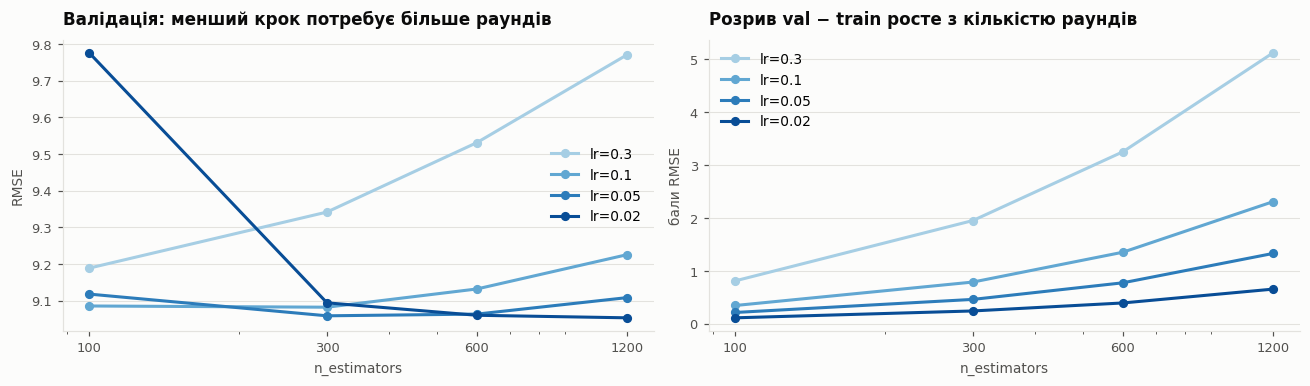

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
for i, lr in enumerate(LR_GRID):
    sub = lr_grid[lr_grid.learning_rate == lr]
    ax.plot(sub.n_estimators, sub.val_rmse, marker='o',
            color=plt.cm.Blues(0.35 + 0.18 * i), label=f'lr={lr}')
ax.set_xscale('log'); ax.set_xticks(N_GRID); ax.set_xticklabels(N_GRID)
ax.set_title('Валідація: менший крок потребує більше раундів')
ax.set_xlabel('n_estimators'); ax.set_ylabel('RMSE'); ax.legend()

ax = axes[1]
for i, lr in enumerate(LR_GRID):
    sub = lr_grid[lr_grid.learning_rate == lr]
    ax.plot(sub.n_estimators, sub.gap, marker='o',
            color=plt.cm.Blues(0.35 + 0.18 * i), label=f'lr={lr}')
ax.set_xscale('log'); ax.set_xticks(N_GRID); ax.set_xticklabels(N_GRID)
ax.set_title('Розрив val − train росте з кількістю раундів')
ax.set_xlabel('n_estimators'); ax.set_ylabel('бали RMSE'); ax.legend()

plt.tight_layout(); plt.show()

Криві для великих `learning_rate` досягають мінімуму й **піднімаються**. Розрив
val − train росте з кількістю раундів для будь-якого кроку.

In [28]:
# Беремо найкращу пару (lr, n) як основу для наступних раундів
best_lr_row = lr_grid.loc[lr_grid.val_rmse.idxmin()]
LR, N_EST = float(best_lr_row.learning_rate), int(best_lr_row.n_estimators)
print(f'раунд 1 -> learning_rate={LR}, n_estimators={N_EST}')

раунд 1 -> learning_rate=0.02, n_estimators=1200


### 4.3. Раунд 2: складність дерев

EDA показав адитивність зв'язків, тож очікую оптимум на невеликій глибині.

In [29]:
DEPTH_GRID = [3, 4, 6, 8, 10]
MCW_GRID = [1, 10, 50]
rows = []
for d in DEPTH_GRID:
    for mcw in MCW_GRID:
        CV.run_cv(tree_pipe(lambda d=d, mcw=mcw: XGBRegressor(
                      n_estimators=N_EST, learning_rate=LR, max_depth=d,
                      min_child_weight=mcw, **XGB_BASE)),
                  X_B, y_B, name=f'32_xgb_d{d}_mcw{mcw}', protocol='B',
                  params={'max_depth': d, 'min_child_weight': mcw}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'max_depth': d, 'min_child_weight': mcw,
                     'val_rmse': r.mean_rmse, 'gap': r.overfit_gap})
depth_grid_xgb = pd.DataFrame(rows)
print(depth_grid_xgb.pivot(index='min_child_weight', columns='max_depth', values='val_rmse').round(4).to_string())
best2 = depth_grid_xgb.loc[depth_grid_xgb.val_rmse.idxmin()]
DEPTH, MCW = int(best2.max_depth), int(best2.min_child_weight)
print(f'\nраунд 2 -> max_depth={DEPTH}, min_child_weight={MCW}')

max_depth             3       4       6       8       10
min_child_weight                                        
1                 9.0732  9.0458  9.0531  9.1043  9.1931
10                9.0738  9.0463  9.0524  9.1020  9.1779
50                9.0731  9.0443  9.0475  9.0821  9.1382

раунд 2 -> max_depth=4, min_child_weight=50


### 4.4. Раунд 3: випадковість по рядках і колонках

У бустингу це передусім регуляризація, а не спосіб зробити дерева різними.

In [30]:
SUB_GRID = [0.7, 0.85, 1.0]
COL_GRID = [0.6, 0.8, 1.0]
rows = []
for s in SUB_GRID:
    for cs in COL_GRID:
        CV.run_cv(tree_pipe(lambda s=s, cs=cs: XGBRegressor(
                      n_estimators=N_EST, learning_rate=LR, max_depth=DEPTH,
                      min_child_weight=MCW, subsample=s, colsample_bytree=cs, **XGB_BASE)),
                  X_B, y_B, name=f'33_xgb_sub{s}_col{cs}', protocol='B',
                  params={'subsample': s, 'colsample_bytree': cs}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'subsample': s, 'colsample_bytree': cs,
                     'val_rmse': r.mean_rmse, 'gap': r.overfit_gap})
sub_grid = pd.DataFrame(rows)
print(sub_grid.pivot(index='subsample', columns='colsample_bytree', values='val_rmse').round(4).to_string())
best3 = sub_grid.loc[sub_grid.val_rmse.idxmin()]
SUB, COL = float(best3.subsample), float(best3.colsample_bytree)
print(f'\nраунд 3 -> subsample={SUB}, colsample_bytree={COL}')

colsample_bytree     0.6     0.8     1.0
subsample                               
0.70              9.0403  9.0347  9.0326
0.85              9.0414  9.0381  9.0349
1.00              9.0478  9.0426  9.0443

раунд 3 -> subsample=0.7, colsample_bytree=1.0


In [31]:
XGB_BEST = dict(n_estimators=N_EST, learning_rate=LR, max_depth=DEPTH,
                min_child_weight=MCW, subsample=SUB, colsample_bytree=COL)
print('Підсумкова конфігурація після трьох раундів:')
for k, v in XGB_BEST.items():
    print(f'  {k:20s} {v}')
print(f'\nвсього конфігурацій перебрано: {len(lr_grid) + len(depth_grid_xgb) + len(sub_grid)}')
print('(повний grid по тих самих сітках коштував би '
      f'{len(LR_GRID)*len(N_GRID)*len(DEPTH_GRID)*len(MCW_GRID)*len(SUB_GRID)*len(COL_GRID)} фітів)')

oof_xgb, _ = CV.run_cv(tree_pipe(lambda: XGBRegressor(**XGB_BEST, **XGB_BASE)),
                       X, y, name='34_xgb_tuned', protocol='A',
                       params={**XGB_BEST, 'search': 'координатний спуск, 3 раунди, Protocol B'})

Підсумкова конфігурація після трьох раундів:
  n_estimators         1200
  learning_rate        0.02
  max_depth            4
  min_child_weight     50
  subsample            0.7
  colsample_bytree     1.0

всього конфігурацій перебрано: 40
(повний grid по тих самих сітках коштував би 2160 фітів)


  fold 1/5  val 9.0373  train 8.9352  8.1s


  fold 2/5  val 8.9780  train 8.9500  8.4s


  fold 3/5  val 9.0022  train 8.9451  8.3s


  fold 4/5  val 9.0085  train 8.9406  8.9s


  fold 5/5  val 9.0096  train 8.9473  8.3s
[34_xgb_tuned]  OOF 9.0072  |  mean 9.0071 ± 0.0189  |  train 8.9436  (gap +0.0635)  |  42s


### 4.5. Early stopping

У фінальній моделі не використовую — кількість раундів зафіксована в 4.2. Але це
найчастіше джерело витоку, тож показую проблему явно.

In [32]:
from sklearn.model_selection import train_test_split

trn_idx, val_idx = next(iter(CV.get_folds('B').split(X_B)))
X_trn, y_trn = X_B.iloc[trn_idx], y_B.iloc[trn_idx]
X_val, y_val = X_B.iloc[val_idx], y_B.iloc[val_idx]

# препроцесор навчається ТІЛЬКИ на навчальній частині фолду
prep = make_preprocessor(scale=False).fit(X_trn)
A_trn, A_val = prep.transform(X_trn), prep.transform(X_val)

ES = dict(n_estimators=3000, learning_rate=LR, max_depth=DEPTH,
          early_stopping_rounds=50, **XGB_BASE)

# ❌ варіант із витоком: зупинка обирається на тому ж наборі, де міряємось
leaky = XGBRegressor(**ES).fit(A_trn, y_trn, eval_set=[(A_val, y_val)], verbose=False)
rmse_leaky = CV.rmse(y_val, leaky.predict(A_val))

# ✅ коректний варіант: зупинка обирається на внутрішньому шматку навчального фолду
Xi, Xe, yi, ye = train_test_split(X_trn, y_trn, test_size=0.1, random_state=C.SEED)
prep_in = make_preprocessor(scale=False).fit(Xi)
clean = XGBRegressor(**ES).fit(prep_in.transform(Xi), yi,
                               eval_set=[(prep_in.transform(Xe), ye)], verbose=False)
rmse_clean = CV.rmse(y_val, clean.predict(prep_in.transform(X_val)))

print(f'❌ зупинка на зовнішньому фолді: {leaky.best_iteration:5d} раундів   RMSE {rmse_leaky:.4f}')
print(f'✅ зупинка на внутрішньому split: {clean.best_iteration:5d} раундів   RMSE {rmse_clean:.4f}')
print(f'\nрізниця: {rmse_leaky - rmse_clean:+.4f} бала')

❌ зупинка на зовнішньому фолді:  1935 раундів   RMSE 9.0571
✅ зупинка на внутрішньому split:  1680 раундів   RMSE 9.0600

різниця: -0.0029 бала


Нечесний варіант: 1935 раундів, RMSE 9.0571. Коректний: 1680 раундів, 9.0600.
Різниця **0.003**.

Мало, бо валідаційний фолд у 50 000 рядків завеликий, щоб підлаштуватись під нього одним
параметром. Руйнівним цей витік був би на малому наборі або при виборі багатьох параметрів.

### 4.6. Нативні категорії

Результат іде окремим рядком: він змінює препроцесинг, а вимога чекпоінта — порівнювати
моделі на однакових фічах.

In [33]:
# Без Pipeline: категорії вже мають dtype='category' із src/data.py
oof_xgb_cat, _ = CV.run_cv(
    lambda: XGBRegressor(**XGB_BEST, enable_categorical=True, **XGB_BASE),
    X, y, name='35_xgb_native_cat', protocol='A',
    params={**XGB_BEST, 'enable_categorical': True, 'note': 'ІНШИЙ препроцесинг — не для порівняння моделей'})

  fold 1/5  val 8.9731  train 8.8618  9.2s


  fold 2/5  val 8.9182  train 8.8733  8.3s


  fold 3/5  val 8.9352  train 8.8710  8.3s


  fold 4/5  val 8.9472  train 8.8658  8.9s


  fold 5/5  val 8.9407  train 8.8696  8.4s
[35_xgb_native_cat]  OOF 8.9429  |  mean 8.9429 ± 0.0179  |  train 8.8683  (gap +0.0746)  |  43s


Нативні категорії дали **8.9429 проти 9.0072**, тобто 0.064 — у вісім разів більше за
весь тюнінг.

> Після ноутбука 04: моє пояснення (більше можливих розрізів) виявилось хибним.
> Розкладання показало, що кодування категорій дає **нуль**, а весь ефект — від обробки
> пропусків (~0.051 категоріальних + ~0.008 числових). Це той самий ефект, що пізніше
> знайшовся як FE-5.

## 5. Підсумок

In [34]:
MAIN = ['00_constant_mean', '01_linear_regression', '02_ridge',
        '10_tree_initial', '13_tree_tuned',
        '20_rf_initial', '23_rf_tuned',
        '30_xgb_initial', '34_xgb_tuned']
res = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
summary = res.loc[[m for m in MAIN if m in res.index]].reset_index()
summary['vs_linear'] = (summary.oof_rmse - res.loc['01_linear_regression'].oof_rmse).round(4)
show(summary, ['name', 'mean_rmse', 'std_rmse', 'oof_rmse', 'train_rmse',
               'overfit_gap', 'fit_seconds', 'vs_linear'])

,name,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds,vs_linear
0,00_constant_mean,18.9183,0.0431,18.9184,18.9183,0.0001,0.0015,9.6708
1,01_linear_regression,9.2476,0.0242,9.2476,9.2458,0.0018,3.3124,0.0000
2,02_ridge,9.2476,0.0242,9.2476,9.2458,0.0018,6.5990,-0.0000
3,10_tree_initial,13.1151,0.0272,13.1151,0.0000,13.1151,16.6206,3.8675
4,13_tree_tuned,9.5378,0.0185,9.5378,8.8555,0.6823,12.2376,0.2902
5,20_rf_initial,9.2388,0.0166,9.2389,3.4568,5.7821,178.0753,-0.0088
6,23_rf_tuned,9.0993,0.0230,9.0993,6.6304,2.4688,209.9540,-0.1483
7,30_xgb_initial,9.0153,0.0209,9.0153,8.5740,0.4414,22.8386,-0.2323
8,34_xgb_tuned,9.0071,0.0189,9.0072,8.9436,0.0635,42.1163,-0.2404


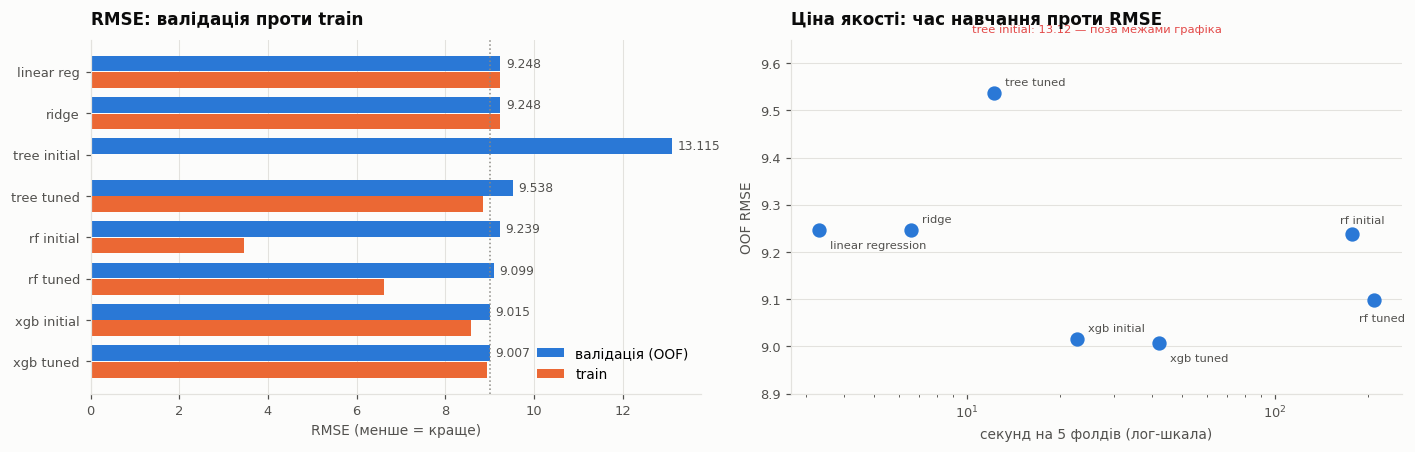

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
d = summary[summary['name'] != '00_constant_mean'].copy()
labels = (d['name'].str.replace(r'^\d+_', '', regex=True)
           .str.replace('_', ' ').str.replace('regression', 'reg'))

ax = axes[0]
ypos = np.arange(len(d))
ax.barh(ypos - 0.2, d.oof_rmse, height=0.38, color=viz.BLUE, label='валідація (OOF)')
ax.barh(ypos + 0.2, d.train_rmse, height=0.38, color=viz.ORANGE, label='train')
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis()
best_line = d.oof_rmse.min()
ax.axvline(best_line, color=viz.INK_MUTED, linewidth=1.0, linestyle=':')
for i, v in enumerate(d.oof_rmse):
    ax.text(v + 0.12, i - 0.2, f'{v:.3f}', va='center', fontsize=8, color=viz.INK_SECONDARY)
ax.set_title('RMSE: валідація проти train')
ax.set_xlabel('RMSE (менше = краще)')
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.legend(loc='lower right')

ax = axes[1]
# tree initial (13.1) стиснув би весь цікавий діапазон 9.0-9.6 в одну смугу,
# тому масштаб обмежено, а сам пункт підписано як такий, що вийшов за межі
usable = d[d.oof_rmse < 10]
ax.scatter(usable.fit_seconds, usable.oof_rmse, s=70, color=viz.BLUE, zorder=3)
offsets = {'linear regression': (7, -12), 'ridge': (7, 5), 'tree tuned': (7, 5),
           'rf initial': (-8, 7), 'rf tuned': (-10, -14),
           'xgb initial': (7, 5), 'xgb tuned': (7, -12)}
for _, r in usable.iterrows():
    lab = r['name'].split('_', 1)[1].replace('_', ' ')
    ax.annotate(lab, (r.fit_seconds, r.oof_rmse), textcoords='offset points',
                xytext=offsets.get(lab, (7, 5)), fontsize=7.5, color=viz.INK_SECONDARY)
off = d[d.oof_rmse >= 10]
if len(off):
    ax.annotate(f'tree initial: {off.oof_rmse.iloc[0]:.2f} — поза межами графіка',
                xy=(0.5, 1.02), xycoords='axes fraction', ha='center',
                fontsize=7.5, color=viz.RED)
ax.set_xscale('log')
ax.set_ylim(8.9, 9.65)
ax.set_title('Ціна якості: час навчання проти RMSE')
ax.set_xlabel('секунд на 5 фолдів (лог-шкала)'); ax.set_ylabel('OOF RMSE')

plt.tight_layout(); plt.show()

**Усі три передбачення EDA підтвердились.** Лінійна регресія відстає від найкращої на
0.24 бала, одиночне дерево програє їй, приріст бустингу скромний.

**Тюнінг дає тим більше, чим менш стійка модель:** дерево 3.58, ліс 0.14, XGBoost 0.008.

**Розрив train/val не є самостійним діагнозом:** у лісу він 5.78 при найкращій на той
момент валідації.

### Що далі

Тюнінг вичерпано: 40 конфігурацій XGBoost дали 0.008, а зміна кодування категорій 0.064.
Важелі в представленні даних.

Опорна модель для ноутбука 03 — налаштований XGBoost на one-hot (9.0072). Її параметри,
рядки та фолди лишаються зафіксованими; обрану зміну фіч додатково перевірятиму на
лінійній регресії.